# 04_概率分布-泊松分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今儿来聊聊，概率分布中的泊松分布\~

泊松分布（Poisson Distribution）是在统计学和概率论中常用来描述单位时间或单位面积内某事件发生次数的概率分布模型。

直观上看，当事件的发生满足以下条件时，可以用泊松分布来描述：

- 事件是随机的且独立发生，即相邻时间或空间单位内的事件发生是相互独立的。
- 在单位时间或单位空间内，事件发生的平均次数 λ（lambda）是一个常数。
- 某个时间段内发生多个事件的概率远低于发生单个事件的概率，即事件发生的概率在短小的时间间隔内可以近似为线性。

简单来说，泊松分布就是在观察到的时间间隔或者空间区域内，描述某种罕见事件的发生次数分布情况。

比如说，在一个繁忙的公交车站，有时我们会关心单位时间内公交车到站次数的概率；又比如说，在一个电话客服中心，我们可能需要分析每分钟内接到的客户来电数是否符合某种随机模式。

**咱们举一个例子：**

假设你每天早上需要在公交站候车，公交车到站是随机的，但是历史记录表明，在早高峰时段，平均每 10 分钟内有 2 辆公交车到来。那么在某个固定的 10 分钟内，公交车的到站次数就可以近似认为服从泊松分布。

- 当 λ = 2 时，若想计算恰好有 3 辆公交车在这 10 分钟内到达的概率，就可以用泊松分布的概率质量函数来计算该概率。
- 类似地，如果你关注的是一分钟内电话呼叫的数量，而这个一分钟内平均收到 0.5 个电话，那么你可以用泊松分布来估计一分钟内收到 0 个、1 个甚至更多电话的概率分布。

这种描述方式重点在于强调事件在一段较短时间内的稀疏性和随机性。由于泊松分布只需要一个参数 λ，就可以完全描述事件发生的统计特性，因此在很多领域中都有广泛的应用，如网络流量分析、地震次数统计、事故发生率、光子计数等。

### 泊松分布的特点

1. **参数单一**：泊松分布由唯一一个参数 λ（平均发生率）决定。λ 越大，事件在单位时间内发生得越频繁，分布的平均值和方差均为 λ。
2. **离散分布**：泊松分布描述的事件次数为非负整数，即可能取 0, 1, 2, … 等离散值。
3. **稀疏性**：对于较小的 λ 值，概率集中在较低的数值上；当 λ 较小时，事件大部分时间内可能根本不发生或仅发生一次。
4. **无记忆性近似**：虽然泊松分布本身不具备完全的无记忆性，但在某些条件下可以类似地理解连续时间内随机事件的间隔特性。

## 公式推导

在数学上，若一个随机事件在单位时间（或者单位面积、单位体积等）内平均发生 λ 次，且事件发生相互独立，那么在固定时间内恰好发生 k 次的概率由下式给出：


$$
P(X=k)=\frac{\lambda^k e^{-\lambda}}{k!}, \quad k=0,1,2,\dots
$$


其中：

$\lambda$为给定时间段内事件的平均发生次数。

$e$是自然对数的底数，大约等于 2.71828。

$k!$是 k 的阶乘。

### 泊松分布的概率质量函数（PMF）

我们可以从模型的基本假设开始推导泊松分布的概率质量函数。设有以下条件：

- 将观察时间 T 划分为 n 个非常小的时间间隔，每个时间间隔为 Δt = T/n。
- 在每个小间隔内，事件发生的概率大致为 $p \approx \lambda \Delta t$（其中 $\lambda \Delta t$很小），且每个时间间隔内只允许发生至多一个事件。

在每个小时间间隔内发生事件可以近似看成一个伯努利试验，若我们认为独立性成立，则总体在 T 内事件总数 $X$可看作 n 次伯努利试验的成功总数，即服从参数为 $n$和成功率 $p$的二项分布：


$$
P(X=k)=\binom{n}{k} (\lambda \Delta t)^k (1-\lambda \Delta t)^{n-k}
$$


这里 $T=1$时 $\Delta t = 1/n$，因此 $\lambda \Delta t=\lambda/n$。

### 数学推导过程与直观解释

考虑极限过程，当 n 趋向于无穷大时，每个小时间间隔内事件发生的概率趋近于 0，但总试验次数 n 趋向于无穷大，这正符合“低概率、大样本”的情况，此时二项分布可以用泊松分布近似。下面介绍详细推导过程：

1. **二项式系数近似：**设 $p=\lambda/n$，当 n 很大时：  
$\binom{n}{k} = \frac{n(n-1)...(n-k+1)}{k!} \approx \frac{n^k}{k!}$  
这是因为对于较小的 k 来说， $n, n-1, \dots, n-k+1$彼此相近，可以近似看作 n 的 k 次方。
2. **指数部分的推导：**注意到：  
$(1-p)^n = \left(1-\frac{\lambda}{n}\right)^n$  
利用极限公式：  
$\lim_{n\to\infty} \left(1-\frac{\lambda}{n}\right)^n = e^{-\lambda}$
3. **整理组合公式：**于是，将二项分布公式写为：  
$P(X=k)=\binom{n}{k} \left(\frac{\lambda}{n}\right)^k \left(1-\frac{\lambda}{n}\right)^{n-k}$  
当 n 趋于无穷大时，上式左边的二项式系数近似为 $\frac{n^k}{k!}$；右侧部分  
$\left(\frac{\lambda}{n}\right)^k \text{和} \left(1-\frac{\lambda}{n}\right)^{n-k} \approx e^{-\lambda}$  
整理得到  
$P(X=k) \approx \frac{n^k}{k!}\cdot \frac{\lambda^k}{n^k}\cdot e^{-\lambda} = \frac{\lambda^k e^{-\lambda}}{k!}$
4. **解释：**这种推导依赖于“稀疏事件”的假设，即把单位时间内的连续过程离散化后，每个小区间内事件发生的概率趋近于零，而整个过程的总体概率却保持有限的 λ。当 n 非常大时，二项分布的极限就是泊松分布，这也解释了为什么在低概率、多试验的情况下会出现泊松分布。

### 与其他分布的关系

一个常见的例子是二项分布和泊松分布之间的联系。当二项分布的试验次数 n 很大，而成功概率 p 很小，并且满足 np=λ 固定时，二项分布 $B(n, p)$会收敛于泊松分布 $Poisson(\lambda)$。

这种关系不仅为泊松分布的数学推导提供了理论基础，也说明了在实际应用中，当事件发生率较低时，我们可以用泊松分布来简化模型并进行估计。

同时，泊松分布与指数分布也有密切联系：对于泊松过程，两个相邻事件之间的时间间隔服从参数为 λ 的指数分布，这反映了“无记忆性”这一特性。

## Python实现

在这部分中，我们利用 Python 生成泊松分布数据，并利用 matplotlib 来进行可视化。

同时，我们也会展示一个简单的机器学习应用示例，探讨如何基于泊松分布构建和评估模型。

### 利用 Python 生成泊松分布数据

下面的代码首先利用 NumPy 生成服从泊松分布的数据，再使用 matplotlib 绘制直方图、概率质量函数曲线，同时也会计算理论概率分布曲线以便做对比：

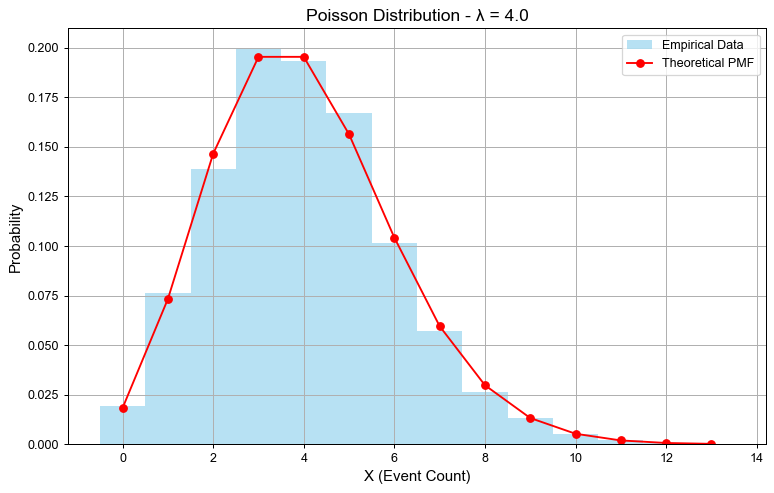

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# 设置随机种子，确保实验可重复
np.random.seed(42)

# 设置泊松分布参数 lambda 值
lam = 4.0  # 平均每单位时间内发生4次事件

# 生成随机数据，假设生成10000个样本
data = np.random.poisson(lam, 10000)

# 计算理论概率质量函数
k_values = np.arange(0, np.max(data)+1)
pmf_values = poisson.pmf(k_values, lam)

# 绘制直方图与理论概率曲线
plt.figure(figsize=(10, 6))
plt.hist(data, bins=np.arange(min(data), max(data)+2)-0.5, density=True, alpha=0.6, color='skyblue', label='Empirical Data')
plt.plot(k_values, pmf_values, 'ro-', label='Theoretical PMF')

plt.xlabel("X (Event Count)", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Poisson Distribution - λ = 4.0", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

- 首先调用 `numpy.random.poisson` 方法生成 10000 个服从参数 λ=4.0 的泊松分布数据。
- 使用 `scipy.stats.poisson.pmf` 函数计算理论概率质量函数的值。
- 利用 matplotlib 画出直方图（经验分布）和理论概率曲线进行直观比较。

![原文参考图，当前结果见代码输出](attachments/img_016.png)

通过上述代码生成的图形可以直观展示出泊松分布的特点：

- 对于低事件数的部分（例如 0、1、2……），理论概率较高，并且直方图的频数与理论概率较为吻合。
- 当 λ 值不同的时候，分布的均值和方差均会跟随变化。  
在实际应用中，我们还可以通过改变参数 λ 来研究不同时段或不同场景下的事件发生规律。

### 基于泊松分布的算法应用

在某些机器学习或数据挖掘任务中，泊松分布常被用来建模计数数据。

例如在文本挖掘中，我们经常需要统计单词在文档中出现的次数，而这些计数数据可能服从泊松分布；在交通流量、网络请求数、设备故障次数等场景中也可以用泊松回归模型进行建模预测。

**案例：泊松回归在交通事故预测中的应用**

假设你希望根据一些影响因素预测某个路段在一定时间内发生交通事故的次数。问题可以形式化为计数回归问题，而泊松回归是一种常用的计数回归方法。

#### 数据集描述

假设我们的数据集包含若干变量：

- **Traffic_Volume**：交通流量（车/小时）
- **Weather_Condition**：天气状况评分
- **Road_Condition**：道路状况评分
- **Accident_Count**：在一定时间内发生交通事故的次数（计数数据）

这些特征中，Accident_Count 是我们的目标变量，通常假定它服从某个参数 λ 的泊松分布。

我们希望通过回归模型建立如下关系：  
$\log(\lambda) = \beta_0 + \beta_1 \cdot Traffic\_Volume + \beta_2 \cdot Weather\_Condition + \beta_3 \cdot Road\_Condition$  
这样，通过对数连接函数，将预测的均值 λ 与输入特征之间的关系线性化，利用最大似然估计得到各参数。

#### 利用 Python 进行泊松回归

这里采用 `statsmodels` 包中的 Generalized Linear Model（GLM）来实现泊松回归。数据部分会使用随机数据来模拟。

   Traffic_Volume  Weather_Condition  Road_Condition  Accident_Count
0      224.835708           6.852355        9.099033               4
1      193.086785           8.818833        8.386951               5
2      232.384427           2.202865        7.089446              10
3      276.151493           6.125938        6.029595              12
4      188.292331           3.698715        8.047335               5
                 Generalized Linear Model Regression Results                  
Dep. Variable:         Accident_Count   No. Observations:                  500
Model:                            GLM   Df Residuals:                      496
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1110.3
Date:                Sat, 12 Sep 2026   Deviance:                       546.07
Time:                        14:3

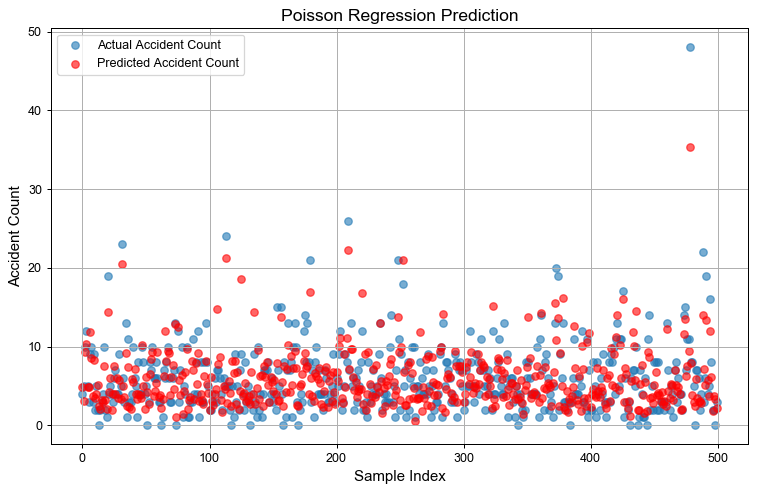

In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

# 模拟数据（假设有 500 个样本）
n_samples = 500

# 生成特征数据，Traffic_Volume, Weather_Condition, Road_Condition
traffic_volume = np.random.normal(200, 50, n_samples)   # 平均200车/小时, 标准差50
weather_condition = np.random.normal(5, 2, n_samples)     # 假设评分范围大致在 0-10
road_condition = np.random.normal(7, 1.5, n_samples)      # 假设评分范围大致在 0-10

# 构建线性预测器，设置系数 β
beta_0 = 0.5
beta_1 = 0.01
beta_2 = -0.1
beta_3 = -0.05

# 计算线性部分 z = β0 + β1*x1 + β2*x2 + β3*x3
z = beta_0 + beta_1 * traffic_volume + beta_2 * weather_condition + beta_3 * road_condition

# 利用指数函数构造 λ
lam_pred = np.exp(z)

# 根据 λ 生成泊松分布下的事故计数
accident_count = np.random.poisson(lam_pred)

# 将数据放入 DataFrame
df = pd.DataFrame({
    'Traffic_Volume': traffic_volume,
    'Weather_Condition': weather_condition,
    'Road_Condition': road_condition,
    'Accident_Count': accident_count
})

print(df.head())

# 定义特征和响应变量
features = df[['Traffic_Volume', 'Weather_Condition', 'Road_Condition']]
features = sm.add_constant(features)  # 加入截距项
target = df['Accident_Count']

# 构建泊松回归模型
poisson_model = sm.GLM(target, features, family=sm.families.Poisson())
poisson_results = poisson_model.fit()

print(poisson_results.summary())

# 对模型进行预测，并绘制实际值与预测值的对比图
predicted_counts = poisson_results.predict(features)

plt.figure(figsize=(10, 6))
plt.scatter(range(n_samples), target, alpha=0.6, label='Actual Accident Count')
plt.scatter(range(n_samples), predicted_counts, alpha=0.6, color='red', label='Predicted Accident Count')
plt.xlabel("Sample Index", fontsize=12)
plt.ylabel("Accident Count", fontsize=12)
plt.title("Poisson Regression Prediction", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

1. **数据模拟：**

   - 我们生成了 500 个样本，并构造了三个特征变量（Traffic_Volume、Weather_Condition、Road_Condition）。
   - 根据预设的线性模型系数（β0, β1, β2, β3）构造了线性预测器 z，并利用指数函数转换为泊松分布的均值 λ。
   - 使用 `numpy.random.poisson` 根据 λ 值生成实际事故次数，作为因变量。
2. **模型构建：**

   - 采用 `statsmodels.api` 中的 GLM 模块来构建泊松回归模型，并指定泊松族（Poisson family）。
   - 模型采用最大似然法拟合，进而输出模型参数、标准误差、Z 值以及 p 值，这些指标有助于解释每个变量对目标变量的影响。
3. **模型预测与可视化：**

   - 模型拟合后，对每个样本计算预测的事故次数，并与实际值进行对比。
   - 绘制散点图展示模型预测结果与实际观察值的分布情况，以此评估模型表现。

![原文参考图，当前结果见代码输出](attachments/img_017.png)

通过上述泊松回归示例，我们可以看到：

- 如何利用泊松分布来处理计数型数据；
- 如何利用对数链接函数将线性模型与计数模型结合；
- 在实际生产中，泊松回归可用于预测电话呼叫数量、网站点击次数、设备故障次数、交通事故发生频率等情境。

此外，该模型还能进行参数显著性检验，帮助我们判断各特征是否对目标变量有显著影响，从而优化系统设计和决策制定。

到这里，大家应该能够：

- 理解泊松分布的定义、特点和应用场景；
- 掌握泊松分布概率质量函数的推导过程，并认识其与二项分布、指数分布的内在联系；
- 利用 Python 编程实践生成泊松分布数据，进行可视化分析；
- 运用泊松回归模型构建计数数据预测任务，并对模型性能进行评估。

在未来的学习中，可以通过进一步阅读相关统计学文献以及在实际项目中不断实践，逐步掌握更多关于随机过程、计数数据建模与广义线性模型的知识。